In [25]:
import pandas as pd
import seaborn as sns


In [26]:
train_data = pd.read_csv("../data/train.csv")
test_data = pd.read_csv("../data/test.csv")


train_data.info()
train_data.head()

# Survived is the target varuable

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
# check columns are numeric or categorical

def check_col_types(table):
    catagorical_cols = [col for col in table.columns if table[col].dtype == 'str']
    numeric_cols = [col for col in table.columns if table[col].dtype != 'str']
    print("Categorical columns:", catagorical_cols)
    print("Numeric columns:", numeric_cols)

check_col_types(train_data)

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numeric columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


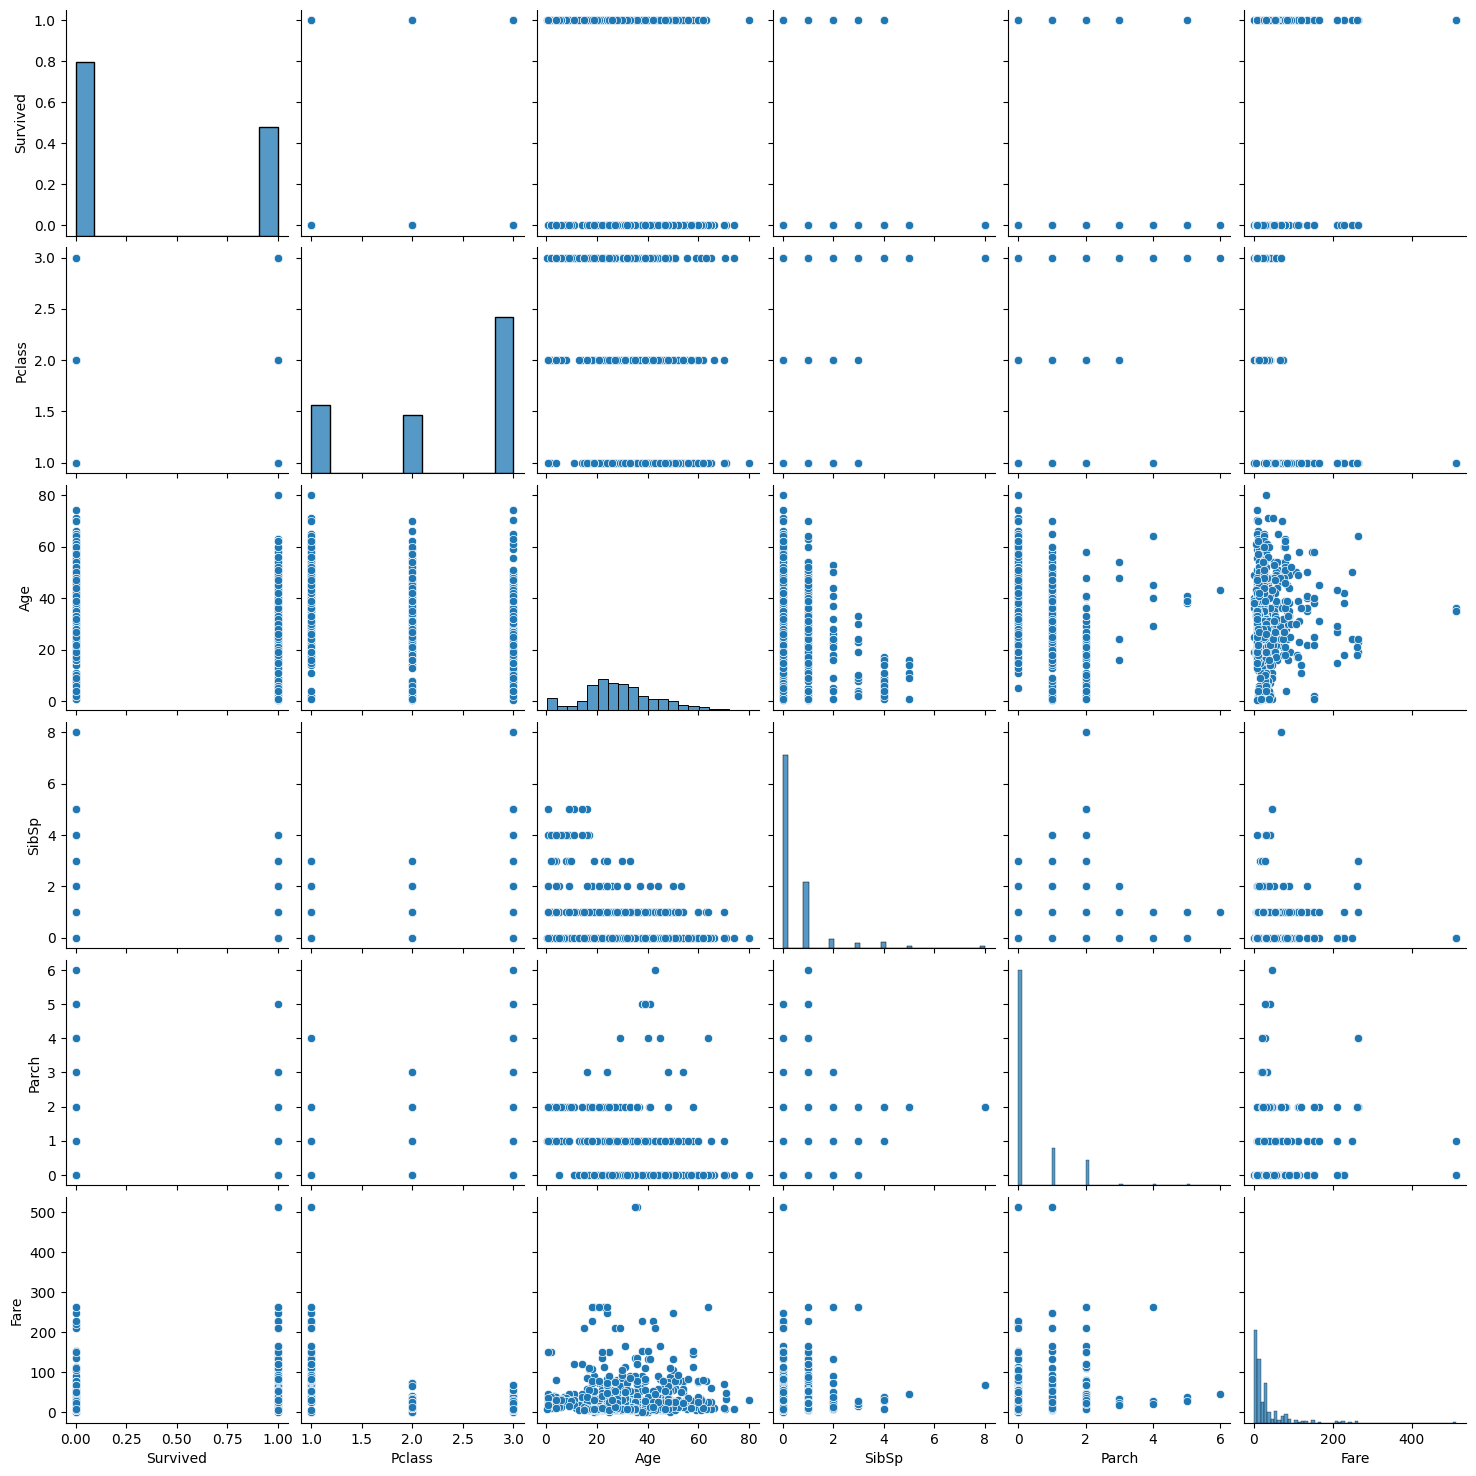

In [28]:
# Relevant Neumeric features for the model :  'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'
sns.pairplot(train_data[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']])

In [29]:
# saw this hint in Kaggel 
train_data['Family_On_Board'] = train_data['SibSp'] + train_data['Parch']
test_data['Family_On_Board'] = test_data['SibSp'] + test_data['Parch']


In [30]:
# Convert Sex column from Male/Female to 1/0
train_data['Sex'] = train_data['Sex'].map({'male': 1, 'female': 0})
test_data['Sex'] = test_data['Sex'].map({'male': 1, 'female': 0})

train_data.head()
check_col_types(train_data)

Categorical columns: ['Name', 'Ticket', 'Cabin', 'Embarked']
Numeric columns: ['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_On_Board']


In [31]:
# Check missing values per column for train and test
def check_if_nan(df):
    print(df.isna().sum())
    print("\nColumns with missing values:")
    print(df.columns[df.isna().any()].tolist())
    print("-"*40 + "\n")

check_if_nan(train_data)

PassengerId          0
Survived             0
Pclass               0
Name                 0
Sex                  0
Age                177
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin              687
Embarked             2
Family_On_Board      0
dtype: int64

Columns with missing values:
['Age', 'Cabin', 'Embarked']
----------------------------------------



In [32]:
# Handle missing values
# but this can be importnat as cabin decided their position and also hints their survival chances, so we can create a new feature to indicate whether the cabin information is missing or not

train_data = train_data.drop(columns=['Cabin'])
test_data = test_data.drop(columns=['Cabin'])


# Fill Age with median
age_median = train_data['Age'].median()
train_data['Age'] = train_data['Age'].fillna(age_median)
test_data['Age'] = test_data['Age'].fillna(age_median)

In [33]:
check_col_types(train_data)

Categorical columns: ['Name', 'Ticket', 'Embarked']
Numeric columns: ['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_On_Board']


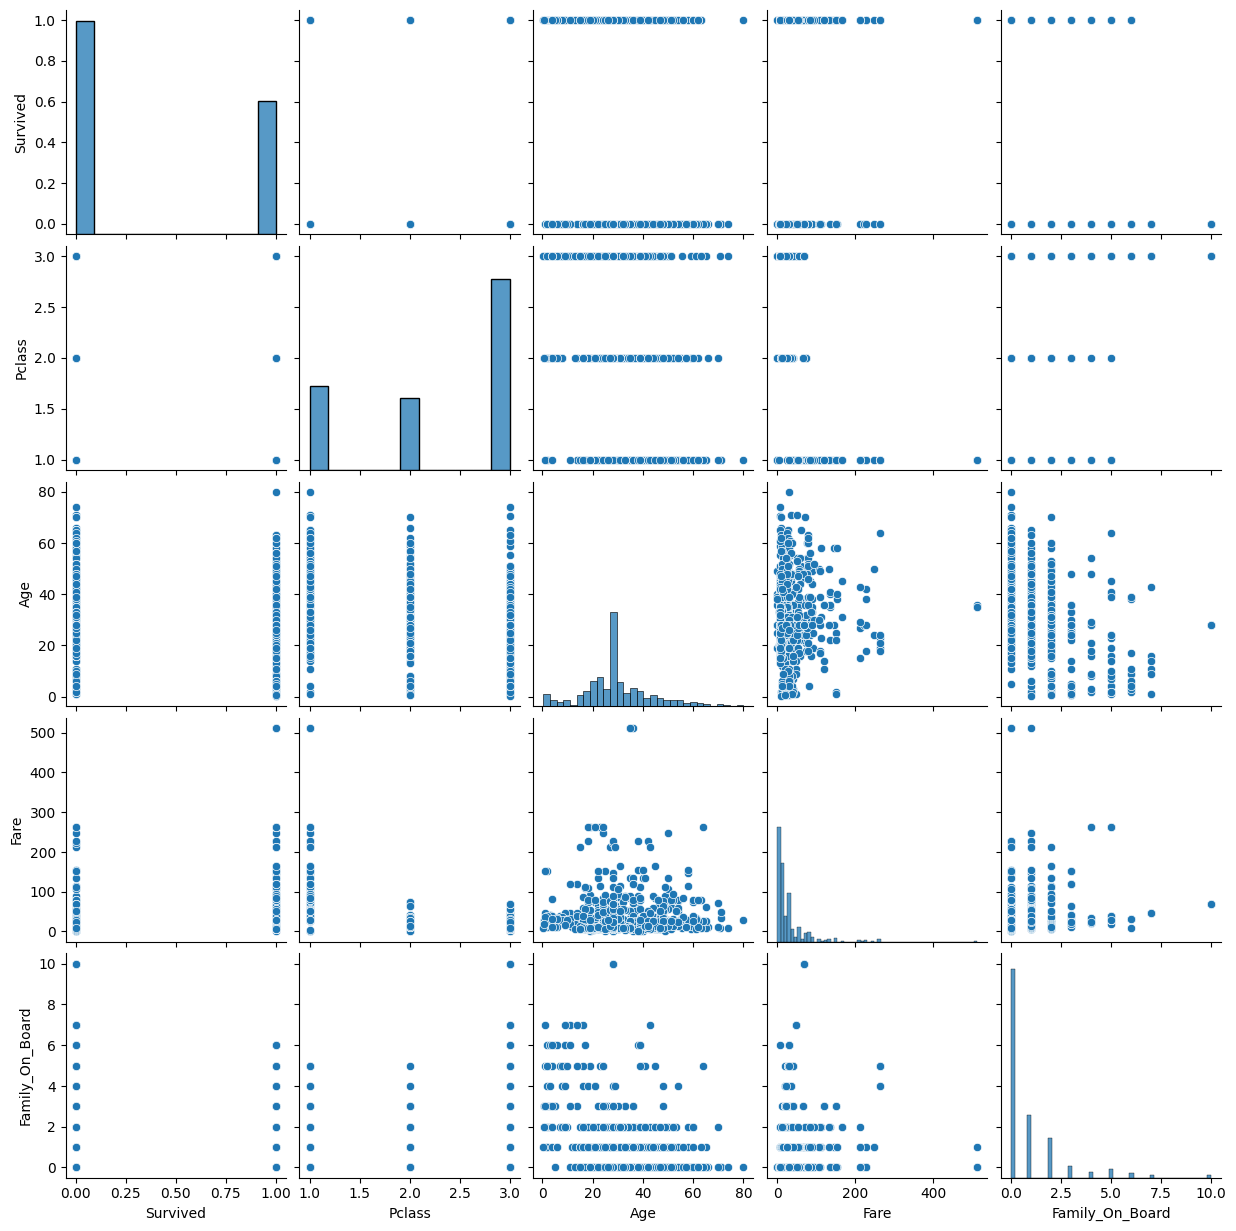

In [34]:
sns.pairplot(train_data[['Survived', 'Pclass', 'Age', 'Fare', 'Family_On_Board']]) 

In [35]:
finalized_features = ['Pclass', 'Age', 'Fare', 'Family_On_Board']
train_data.to_csv("../data/processed_train.csv", index=False)
test_data.to_csv("../data/processed_test.csv", index=False)